# Linear Regression :
This the tutorial about simple linear regression. At the end of this you are able to build a simple linear model to predict continuous outcome variable based upon multiple independent variables.


---



# Q. What is regression ?
In statistical modeling, regression analysis is a statistical method for estimating the relationship between a dependent variable (often called the outcome or response variable, or a label in machine learning parlance) and one or more independent variables (often called regressors, predictors, covariates, explanatory variables or features)

y = bo + yx



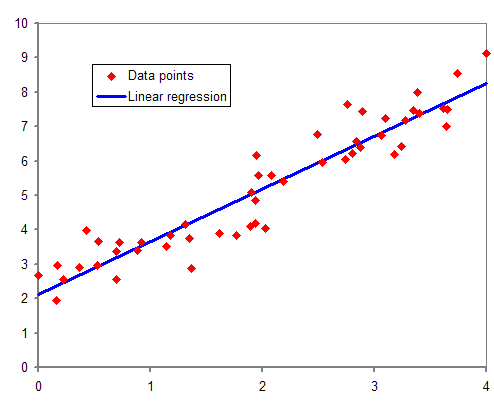

# Q. What is Linear Regression ?
In statistics, linear regression is a model that estimates the relationship between a scalar response (dependent variable) and one or more explanatory variables (regressor or independent variable).


---



# Step by Step Guide to Build Linear Regression Model
* *note : There are not any fixed universal steps for modeling. You just need to understand the concept behind it.*

# Step 1 : Load Dataset

In [2]:
import pandas as pd
from google.colab import files
files.upload()
df = pd.read_csv('income_dataset.csv')

Saving income_dataset.csv to income_dataset.csv


In [6]:
df.head(10)

,education_years,age,experience,income
0,10,60,43,128449
1,15,50,29,93246
2,13,36,19,86091
3,18,29,6,72305
4,10,42,29,92460
5,8,60,49,123398
6,10,40,24,81925
7,12,44,27,90292
8,10,32,15,51855
9,8,32,19,69456


# Step 2 : Data Exploration

In [7]:
# Findout the Data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   education_years  100 non-null    int64
 1   age              100 non-null    int64
 2   experience       100 non-null    int64
 3   income           100 non-null    int64
dtypes: int64(4)
memory usage: 3.3 KB


In [10]:
# Basic Univariate Data analysis
df.describe()

,education_years,age,experience,income
count,100.00000,100.000000,100.000000,100.000000
mean,12.87000,40.430000,22.660000,90184.310000
std,3.32622,11.149358,11.636949,22501.266964
min,8.00000,22.000000,0.000000,47768.000000
25%,10.00000,30.000000,14.000000,72463.250000
50%,13.00000,41.500000,23.000000,87862.000000
75%,16.00000,49.000000,31.000000,105060.500000
max,18.00000,60.000000,49.000000,137316.000000


In [9]:
# Findout the total number null values per column.
df.isnull().sum()

,0
education_years,0
age,0
experience,0
income,0


## * *Concept: Know your variables, data types, missing values, and distributions before modeling*

## Step 3 : Define your X and y
Concept :
*   X = predictors/ features
*   y = outcome/ target




In [13]:
X = df[['education_years', 'age', 'experience']]
y = df['income']

# Step 4 : Split the data :
Split your data into train and test dataset

*Concept: Train on one portion, evaluate on unseen data.*

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 3), (20, 3), (80,), (20,))

# Step 5 : Fit Linear Regression


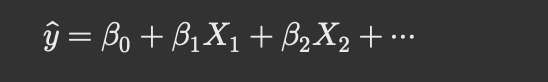

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Step 6: Predict

In [23]:
y_predict = model.predict(X_test)

# Step 7 : 7. Evaluate

The minimum important metrics:

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_predict)
rmse = mean_squared_error(y_test, y_predict) ** 0.5
r2 = r2_score(y_test, y_predict)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2: ", r2)

MAE:  7062.811261809169
RMSE:  8702.182750588356
R2:  0.8469809695530564


# Steps 8 :Examine intercept and coefficients

In [43]:
# beta intercept (bo) :
# Core interpretation: Holding other predictors constant, a 1-unit increase in X is associated with a β-unit change in predicted Y.

model.intercept_

np.float64(8069.937291570706)

In [44]:
# beta Coefficient for each independent variables

model.coef_

array([1027.8659148 , 1363.32240341,  563.17151187])

In [39]:
pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

,Variable,Coefficient
0,education_years,1027.865915
1,age,1363.322403
2,experience,563.171512


# Step 9 : Diagnostics : This part beginners often skip
*A regression is not finished just because you calculated R².*

In [47]:
# Residuals

residuals = y_test - y_predict
residuals

,income
83,14831.772870
53,-4871.672146
70,-3728.672368
45,-3771.513722
44,15670.192393
39,7829.469471
22,7250.811119
80,10574.347098
10,9311.532757
0,4084.684345


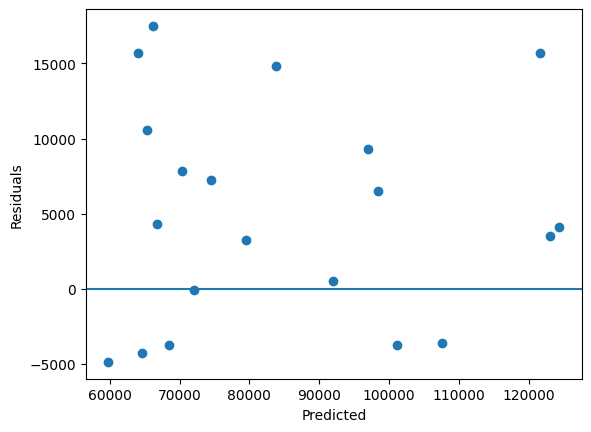

In [50]:
# Residual plot
import matplotlib.pyplot as plt

plt.scatter(y_predict, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

#You want residuals to look roughly randomly scattered around zero.

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df[['education_years', 'age', 'experience']]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_predict = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_predict))
print("RMSE:", mean_squared_error(y_test, y_predict)**0.5)
print("R²:", r2_score(y_test, y_predict))
print("Coefficients:", model.coef_)

MAE: 7062.811261809169
RMSE: 8702.182750588356
R²: 0.8469809695530564
Coefficients: [1027.8659148  1363.32240341  563.17151187]


# Another Statistical methods

In [55]:
import statsmodels.api as sm

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     254.9
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           1.39e-45
Time:                        16:33:45   Log-Likelihood:                -1033.8
No. Observations:                 100   AIC:                             2076.
Df Residuals:                      96   BIC:                             2086.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.148e+04   4551.787     

## The End